# MPA-MLF Final Project — Room Occupancy Classification
**Author:** Rafael Estévez Marrero  
**Task:** Classify number of persons (0, 1, 2, 3) in a room from 60 GHz delay-Doppler snapshots  
**Dataset:** PNG images (delay-Doppler domain)  

---
## 0. Setup & Drive Mount

In [4]:
# Mount Google Drive (datasets must be uploaded there)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ── CONFIGURE PATHS (Unzipped version) ───────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/MPA_MLF_Final'   # ← Change only if your folder name is different

TRAIN_DIR   = f'{BASE_DIR}/x_train'
TEST_DIR    = f'{BASE_DIR}/x_test'
Y_TRAIN_CSV = f'{BASE_DIR}/y_train_v2.csv'
SUBM_CSV    = f'{BASE_DIR}/y_test_submission_example_v2.csv'

import os

print("Checking folders...")
if os.path.exists(TRAIN_DIR):
    train_files = sorted(os.listdir(TRAIN_DIR))
    print(f'Train images found: {len(train_files)}')
    print('Sample train files:', train_files[:5])
else:
    print(f'Train folder not found: {TRAIN_DIR}')

if os.path.exists(TEST_DIR):
    test_files = sorted(os.listdir(TEST_DIR))
    print(f'Test images found: {len(test_files)}')
else:
    print(f'Test folder not found: {TEST_DIR}')

Checking folders...
Train images found: 9227
Sample train files: ['img_1.png', 'img_10.png', 'img_100.png', 'img_1000.png', 'img_1001.png']
Test images found: 3955


## 1. Imports & Reproducibility

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Exploratory Data Analysis

   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2
5   5       1
6   6       3
7   7       2
8   8       2
9   9       3

Total training samples: 9227

Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64


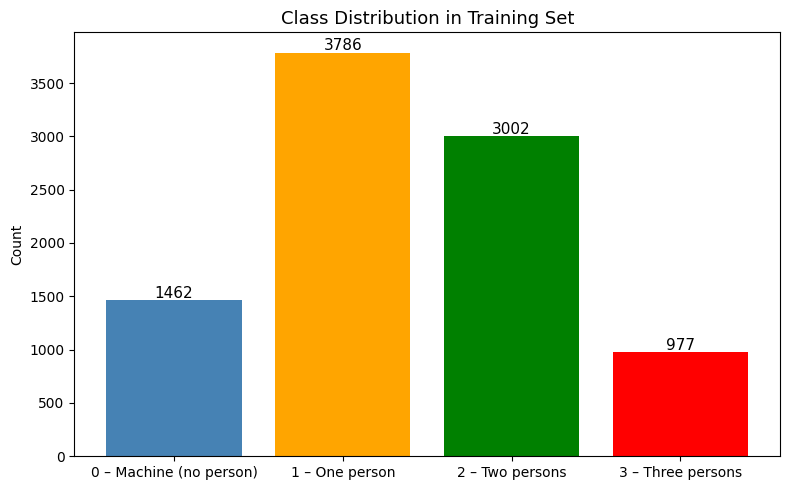

In [9]:
# 2. Exploratory Data Analysis
y_train_df = pd.read_csv(Y_TRAIN_CSV)
print(y_train_df.head(10))
print(f'\nTotal training samples: {len(y_train_df)}')
print('\nClass distribution:')
print(y_train_df['target'].value_counts().sort_index())

# Plot class distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = y_train_df['target'].value_counts().sort_index()
ax.bar(['0 – Machine (no person)', '1 – One person',
        '2 – Two persons', '3 – Three persons'],
       counts.values, color=['steelblue','orange','green','red'])
ax.set_title('Class Distribution in Training Set', fontsize=13)
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Dataset & Data Augmentation

In [51]:
# 3. Dataset & Data Augmentation - Cached Version (Fast for Google Drive)
IMG_SIZE = 64

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class DelayDopplerDataset(Dataset):
    def __init__(self, img_dir, labels_df=None, transform=None, is_test=False):
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        self.cache = {}  # Cache images in RAM

        if not is_test:
            self.ids = labels_df['id'].values
            self.labels = labels_df['target'].values
        else:
            fnames = sorted(os.listdir(img_dir))
            self.fnames = fnames
            self.img_ids = [int(f.replace('.png', '').replace('img_', '').strip()) for f in fnames]

    def __len__(self):
        if not self.is_test:
            return len(self.ids)
        else:
            return len(self.fnames)

    def __getitem__(self, idx):
        if not self.is_test:
            file_id = int(self.ids[idx])
            img_name = f'img_{file_id + 1}.png'
        else:
            img_name = self.fnames[idx]

        # Use cache if available
        if img_name in self.cache:
            img = self.cache[img_name]
        else:
            img_path = os.path.join(self.img_dir, img_name)
            img = Image.open(img_path).convert('RGB')
            self.cache[img_name] = img   # Save to cache

        if self.transform:
            img = self.transform(img)

        label = int(self.labels[idx]) if not self.is_test else -1
        return img, label

In [52]:
# Train / Validation split (80/20 stratified)
train_df, val_df = train_test_split(
    y_train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_df['target']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Training samples  : {len(train_df)}')
print(f'Validation samples: {len(val_df)}')

Training samples  : 7381
Validation samples: 1846


In [53]:
# Create datasets and dataloaders - Optimized version
train_dataset = DelayDopplerDataset(TRAIN_DIR, train_df, transform=train_transforms)
val_dataset   = DelayDopplerDataset(TRAIN_DIR, val_df,   transform=val_transforms)
test_dataset  = DelayDopplerDataset(TEST_DIR, transform=val_transforms, is_test=True)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 116, val: 29, test: 62


## 4. Model — EfficientNet-B0 (Transfer Learning)

In [54]:
# 4. Model — EfficientNet-B0
def build_model(num_classes=4):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=4).to(DEVICE)
print(model.classifier)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=4, bias=True)
)

Trainable parameters: 4,337,024


## 5. Training Setup

In [55]:
# 5. Training Setup
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', classes=np.array([0,1,2,3]), y=train_df['target'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 3
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Class weights: [1.57848589 0.60919445 0.76853394 2.35965473]


## 6. Training Loop

In [56]:
# 6. Training Functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

## 7. Training Curves

In [57]:
# 7. Training Loop with Time Measurement
import time

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
CKPT_PATH = '/content/best_model.pth'

EPOCHS = 5   # Start with 5 epochs for testing. Change to 40 later if it works well.

print("Starting training...\n")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CKPT_PATH)
        star = ' ★ saved'
    else:
        star = ''

    epoch_time = time.time() - start_time

    if epoch % 1 == 0 or epoch == 1:   # Print every epoch during testing
        print(f'Epoch [{epoch:02d}/{EPOCHS}]  '
              f'Train Acc: {tr_acc:.4f}  |  Val Acc: {va_acc:.4f}{star}  '
              f'({epoch_time:.1f}s)')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Starting training...



KeyboardInterrupt: 

## 8. Evaluation on Validation Set

In [39]:
# 8. Evaluation on Validation Set
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

_, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)

print(f'Validation Accuracy: {val_acc:.4f}')
print(f'Macro F1-score: {f1_score(val_labels, val_preds, average="macro"):.4f}')
print(f'Weighted F1-score: {f1_score(val_labels, val_preds, average="weighted"):.4f}')

print('\nClassification Report:')
CLASS_NAMES = ['0 – Machine (no person)', '1 person', '2 persons', '3 persons']
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1','2','3'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Validation Set')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.pth'

## 9. Fine-Tuning Run (optional second stage)

If accuracy is not satisfying, run this cell to do a second fine-tuning pass with a lower learning rate and all layers unfrozen.

In [ ]:
# 9. Test Set Predictions & Kaggle Submission
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc='Predicting test set'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

print(f'Total test predictions: {len(all_preds)}')

# Create submission file
test_img_ids = test_dataset.img_ids
test_label_ids = [x - 1 for x in test_img_ids]

submission_df = pd.DataFrame({'id': test_label_ids, 'target': all_preds})
submission_df = submission_df.sort_values('id').reset_index(drop=True)

SUBMISSION_PATH = '/content/submission.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(submission_df.head(10))
print('\nPrediction distribution:')
print(submission_df['target'].value_counts().sort_index())
print(f'\nSubmission saved to: {SUBMISSION_PATH}')

## 10. Test Set Predictions & Kaggle Submission

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc='Predicting test set'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

print(f'Total test predictions: {len(all_preds)}')

In [ ]:
# Build submission DataFrame matching the required format
subm_example = pd.read_csv(SUBM_CSV)

# Test image IDs (filename numbers → label id = filename_number - 1)
test_img_ids = test_dataset.img_ids          # list of filename numbers, e.g. [9228, 9229, ...]
test_label_ids = [x - 1 for x in test_img_ids]   # convert to label id

submission_df = pd.DataFrame({'id': test_label_ids, 'target': all_preds})
submission_df = submission_df.sort_values('id').reset_index(drop=True)

print(submission_df.head(10))
print(f'\nPrediction distribution:')
print(submission_df['target'].value_counts().sort_index())

SUBMISSION_PATH = '/content/submission.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f'\nSaved to: {SUBMISSION_PATH}')

In [ ]:
# Download submission file
from google.colab import files
files.download(SUBMISSION_PATH)

## 11. Summary

| Metric | Value |
|--------|-------|
| Architecture | EfficientNet-B0 (ImageNet pretrained) |
| Input size | 64×64 RGB |
| Data augmentation | HFlip, VFlip, Rotation±15°, ColorJitter, GaussianBlur |
| Regularisation | Dropout (0.4+0.3), Weight decay (1e-4), BatchNorm1d |
| Optimiser | AdamW, lr=1e-3 → CosineAnnealing |
| Class imbalance | CrossEntropyLoss with class weights |
| Epochs (total) | 40 + 20 fine-tune |
| Best Val Accuracy | *see above* |
| Macro F1 | *see above* |